In [164]:
import numpy as np
import matplotlib.pyplot as plt
from inktime import rgbkm
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import cv2

from sklearn.cluster import MiniBatchKMeans
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import connected_components
from scipy.sparse import coo_matrix

In [218]:
class WoodblockDecomposer:

    def __init__(self, image_path):
        self.img = cv2.imread(image_path)
        self.img = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)
        self.h, self.w, _ = self.img.shape

        # State — populated as you run each step
        self.img_preprocessed  = None
        self.img_lab           = None
        self.magnitude         = None
        self.gx                = None
        self.gy                = None
        self.labels            = None   # evolves: initial → merged → refined

    # ── Step 1 ───────────────────────────────────────────────────────────────
    def preprocess(self, sigma_c=20, sigma_s=8, d=20):
        self.img_preprocessed = preprocessing(self.img, sigma_c, sigma_s, d)
        self.img_lab = cv2.cvtColor(self.img_preprocessed, cv2.COLOR_RGB2LAB)
        return self   # return self so you can chain calls

    # ── Step 2 ───────────────────────────────────────────────────────────────
    def compute_gradients(self, deriv_sigma=0.5, integration_sigma = 0.5):
        self.magnitude, self.gx, self.gy = dizenzo_gradient(
            self.img, deriv_sigma=deriv_sigma)
        return self

    # ── Step 3 ───────────────────────────────────────────────────────────────
    def segment_colors(self, k_initial=30, merge_threshold=18):
        centroids, labels, _ = over_cluster(self.img_lab, k_initial)
        self.centroids, self.labels, _ = merge_close_colors(
            self.img_lab, centroids, labels, merge_threshold
        )
        return self

    # ── Step 4 ───────────────────────────────────────────────────────────────
    def merge_boundaries(self, merge_threshold=0.22,
                               coherence_threshold=0.93, 
                               integration_sigma =  0.3):
        self.labels = self.labels.reshape(self.h, self.w)
        self.labels = gradient_spatial_merge(
            self.labels, self.gx, self.gy,
            merge_threshold, coherence_threshold
        )
        return self

    # ── Visualisation ────────────────────────────────────────────────────────
    def show_layers(self):
        self.labels = self.labels.reshape(self.h, self.w)
        for label in np.unique(self.labels):
            mask = self.labels == label
            canvas = np.ones_like(self.img) * 255
            canvas[mask] = self.img[mask]
            plt.imshow(canvas); plt.axis('off'); plt.show()

    def show_gradient(self):
        plt.imshow(self.magnitude, cmap='gray')
        plt.title('Di Zenzo gradient magnitude')
        plt.axis('off'); plt.show()

## Functions

In [221]:
def preprocessing(img, sigma_c = 20, sigma_s = 8, d =20):
    """Increases contrast using CLAHE and removes noise with bilateralFilter"""

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    
    # Bilateral filtering on L channel
    L_filtered = cv2.bilateralFilter(
        L,
        d= d,               # neighborhood diameter
        sigmaColor=sigma_c,     # range sigma (intensity)
        sigmaSpace=sigma_s       # spatial sigma
    )
    
    # Recombine
    lab_filtered = cv2.merge((L_filtered, a, b))
    result = cv2.cvtColor(lab_filtered, cv2.COLOR_LAB2BGR)
    
    return result

In [267]:
def dizenzo_gradient(img_rgb,
                     ksize=3,
                     deriv_sigma=0.5,
                     integration_sigma=0):
    """
    Multichannel Di Zenzo gradient.

    Parameters
    ----------
    img_rgb : (H, W, 3)
    ksize : Sobel kernel size
    deriv_sigma : Gaussian smoothing before derivatives
    integration_sigma : Gaussian smoothing of tensor components

    Returns
    -------
    gx : (H, W) float32
        x-component of dominant vector gradient
    gy : (H, W) float32
        y-component of dominant vector gradient
    magnitude : (H, W) float32
        sqrt(lambda1)
    """

    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)

    # --- Derivative scale smoothing ---
    if deriv_sigma > 0:
        lab = cv2.GaussianBlur(lab, (0, 0), deriv_sigma)

    H, W = lab.shape[:2]

    A = np.zeros((H, W), np.float32)
    B = np.zeros((H, W), np.float32)
    C = np.zeros((H, W), np.float32)

    # --- Accumulate structure tensor ---
    for c in range(3):
        gx_c = cv2.Sobel(lab[:, :, c], cv2.CV_32F, 1, 0, ksize=ksize)
        gy_c = cv2.Sobel(lab[:, :, c], cv2.CV_32F, 0, 1, ksize=ksize)

        A += gx_c * gx_c
        B += gx_c * gy_c
        C += gy_c * gy_c

    # --- Integration scale smoothing (true structure tensor) ---
    if integration_sigma > 0:
        A = cv2.GaussianBlur(A, (0, 0), integration_sigma)
        B = cv2.GaussianBlur(B, (0, 0), integration_sigma)
        C = cv2.GaussianBlur(C, (0, 0), integration_sigma)

    # --- Eigen decomposition of 2x2 tensor ---
    tmp = np.sqrt((A - C)**2 + 4 * B**2)

    lambda1 = 0.5 * (A + C + tmp)

    magnitude = np.sqrt(A+C) #np.sqrt(lambda1)

    # --- Dominant eigenvector (corresponding to lambda1) ---
    vx = 2 * B
    vy = C - A + tmp

    norm = np.sqrt(vx**2 + vy**2) + 1e-8
    vx /= norm
    vy /= norm

    # --- Final vector gradient ---
    gx = magnitude * vx
    gy = magnitude * vy

    return magnitude.astype(np.float32), gx.astype(np.float32), gy.astype(np.float32) 

In [269]:
def over_cluster(img_lab, k_initial = 30, batch_size = 10000, random_state = 42, n_init = 10):
    h, w, _ = img_lab.shape
    pixels = img_lab.reshape(-1, 3)
    k_initial = 30  # overspecify

    # Mini Batch K-means: takes a random subset and performs k-means
    kmeans = MiniBatchKMeans(
        n_clusters=k_initial,
        batch_size=batch_size,
        random_state=random_state,
        n_init=n_init
    )

    labels = kmeans.fit_predict(pixels) # labels shape (HxW)
    centroids = np.array(kmeans.cluster_centers_)  # color centers (k)

    segmented_lab = centroids[labels]
    segmented_lab = segmented_lab.reshape(h, w, 3).astype(np.uint8)
    return centroids, labels, segmented_lab

In [271]:
def merge_close_colors(img_lab, centroids, labels, merge_threshold = 13):
    h, w, _ = img_lab.shape
    # Compute centroid distances
    dist_matrix = cdist(centroids, centroids)
    
    # Build adjacency matrix
    adj_matrix = dist_matrix < merge_threshold
    np.fill_diagonal(adj_matrix, False)  # remove self-connections
    
    # Connected components (cluster merging)
    n_components, component_labels = connected_components(adj_matrix, directed=False)
    
    print(f"Initial clusters: {len(centroids)}")
    print(f"Final merged clusters: {n_components}")
    
    # Relabel pixels
    final_labels = component_labels[labels]
    
    # Compute final centroids
    final_centroids = np.zeros((n_components, 3))
    pixels = img_lab.reshape(-1,3)
    
    for comp in range(n_components):
       mask = final_labels == comp
       final_centroids[comp] = pixels[mask].mean(axis=0)

    final_centroids = np.array(final_centroids)

    segmented_lab = final_centroids[final_labels]
    segmented_lab = segmented_lab.reshape(h, w, 3).astype(np.uint8)
    
    return final_centroids, final_labels , segmented_lab


In [273]:
def boundary_tensor_coherence(edges_a, edges_b, gx_vals, gy_vals, n_labels):
    """
    Compute structure tensor coherence per region boundary pair.
    
    Parameters
    ----------
    edges_a, edges_b : (N,) int
        Region label pairs (min/max ordered).
    gx_vals, gy_vals : (N,) float
        Gradient x/y values at each boundary pixel.
    n_labels : int

    Returns
    -------
    unique_pairs : (K,) int   encoded pair IDs
    coherence    : (K,) float in [0, 1]  1 = sharp directed edge
    mean_energy  : (K,) float  mean gradient power per boundary pixel
    """

    pair_ids = edges_a * n_labels + edges_b
    unique_pairs, inv = np.unique(pair_ids, return_inverse=True)
    counts = np.bincount(inv).astype(np.float32) + 1e-8

    # --- Accumulate structure tensor components, then AVERAGE ---
    A = np.bincount(inv, weights=gx_vals ** 2) / counts   # <gx^2>
    B = np.bincount(inv, weights=gx_vals * gy_vals) / counts  # <gx*gy>
    C = np.bincount(inv, weights=gy_vals ** 2) / counts   # <gy^2>

    # --- Eigenvalues of the 2x2 structure tensor ---
    tmp = np.sqrt((A - C) ** 2 + 4 * B ** 2)
    lambda1 = 0.5 * (A + C + tmp)   # dominant eigenvalue
    lambda2 = 0.5 * (A + C - tmp)   # minor eigenvalue

    # Coherence in [0, 1]:  0 = isotropic / no clear edge
    #                        1 = perfectly directed edge
    coherence = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8)

    # Mean gradient energy = average trace of structure tensor
    mean_energy = lambda1 + lambda2   # already averaged (divided by counts above)

    return unique_pairs, coherence, mean_energy


In [275]:
def gradient_spatial_merge(labels, gx, gy,
                               merge_threshold=0.15,
                               coherence_threshold=0.6,
                               integration_sigma=0.5):
    """
    Merge labeled regions based on boundary-restricted structure tensor coherence.

    Parameters
    ----------
    labels : (H, W) int
    gx, gy : (H, W) float32   Di Zenzo gradient components
    merge_threshold      : float  normalised energy threshold  [0..1]
    coherence_threshold  : float  structure tensor coherence threshold [0..1]
    integration_sigma    : float  Gaussian sigma applied to gradient maps
                                  before extraction (0 = disabled)

    Returns
    -------
    merged_labels : (H, W) int
    """

    labels = labels.astype(np.int32)
    H, W = labels.shape

    unique_labels, relabeled = np.unique(labels, return_inverse=True)
    labels = relabeled.reshape(H, W)
    n_labels = len(unique_labels)

    # -------------------------------------------------------
    # 1. APPLY INTEGRATION SMOOTHING ON FULL 2D GRADIENT MAPS
    #    (correct way to do neighbourhood pooling)
    # -------------------------------------------------------
    if integration_sigma > 0:
        gx_s = cv2.GaussianBlur(gx, (0, 0), integration_sigma)
        gy_s = cv2.GaussianBlur(gy, (0, 0), integration_sigma)
    else:
        gx_s = gx.copy()
        gy_s = gy.copy()

    # -------------------------------------------------------
    # 2. BOUNDARY EXTRACTION (8-CONNECTED)
    # -------------------------------------------------------
    shifts = [(0, 1), (1, 0), (1, 1), (1, -1)]

    edges_a_list = []
    edges_b_list = []
    edge_gx_list = []
    edge_gy_list = []

    for dy, dx in shifts:
        y1 = slice(None); y2 = slice(None)
        x1 = slice(None); x2 = slice(None)

        if dy == 1:
            y1 = slice(1, None); y2 = slice(0, -1)
        if dx == 1:
            x1 = slice(1, None); x2 = slice(0, -1)
        if dx == -1:
            x1 = slice(0, -1);  x2 = slice(1, None)

        L1 = labels[y1, x1]
        L2 = labels[y2, x2]
        mask = L1 != L2
        if not np.any(mask):
            continue

        a = L1[mask]
        b = L2[mask]
        pairs = np.stack([np.minimum(a, b), np.maximum(a, b)], axis=1)

        edges_a_list.append(pairs[:, 0])
        edges_b_list.append(pairs[:, 1])
        edge_gx_list.append(gx_s[y1, x1][mask])
        edge_gy_list.append(gy_s[y1, x1][mask])

    if len(edges_a_list) == 0:
        return labels.copy()

    edges_a   = np.concatenate(edges_a_list)
    edges_b   = np.concatenate(edges_b_list)
    edge_gx   = np.concatenate(edge_gx_list)
    edge_gy   = np.concatenate(edge_gy_list)

    # -------------------------------------------------------
    # 3. COMPUTE BOUNDARY STATISTICS (FIXED TENSOR)
    # -------------------------------------------------------
    unique_pairs, coherence, mean_energy = boundary_tensor_coherence(
        edges_a, edges_b, edge_gx, edge_gy, n_labels
    )

    # Robust normalisation: divide by 98th percentile, clip to [0, 1]
    p98 = np.percentile(mean_energy, 98)
    mean_energy_norm = np.clip(mean_energy / (p98 + 1e-8), 0.0, 1.0)

    #print(f"coherence     min/max : {coherence.min():.4f} / {coherence.max():.4f}")
    #print(f"mean_energy   min/max : {mean_energy_norm.min():.4f} / {mean_energy_norm.max():.4f}")

    low_energy    = mean_energy_norm < merge_threshold
    low_coherence = coherence        < coherence_threshold
    weak = low_energy & low_coherence

    print(f"low_energy    : {low_energy.sum():4d} / {len(weak)}")
    print(f"low_coherence : {low_coherence.sum():4d} / {len(weak)}")
    print(f"weak (AND)    : {weak.sum():4d} / {len(weak)}")

    # Optional: combined score (uncomment to use instead of OR)
    # score = mean_energy_norm * (0.5 + 0.5 * coherence)
    # weak  = score < merge_threshold

    print(f"Boundaries to merge : {weak.sum()} / {len(weak)}")

    if not np.any(weak):
        print("No weak boundaries found - try relaxing thresholds.")
        return labels.copy()

    selected_pairs = unique_pairs[weak]

    # -------------------------------------------------------
    # 5. GRAPH MERGING
    # -------------------------------------------------------
    a = selected_pairs // n_labels
    b = selected_pairs  % n_labels

    row  = np.concatenate([a, b])
    col  = np.concatenate([b, a])
    data = np.ones(len(row), dtype=np.uint8)

    graph = coo_matrix((data, (row, col)), shape=(n_labels, n_labels))
    _, component_labels = connected_components(graph, directed=False)

    merged_labels = component_labels[labels]
    return merged_labels

Initial clusters: 30
Final merged clusters: 13


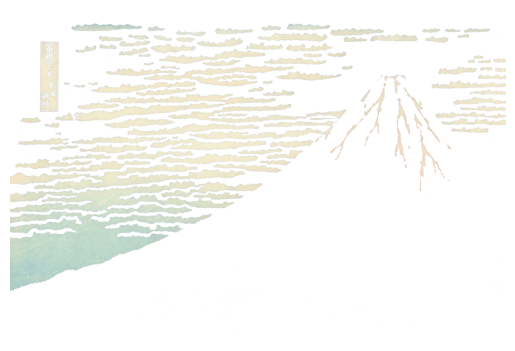

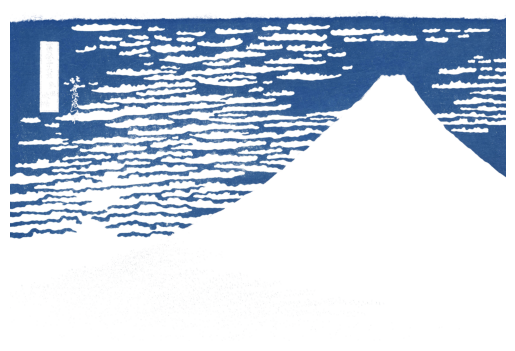

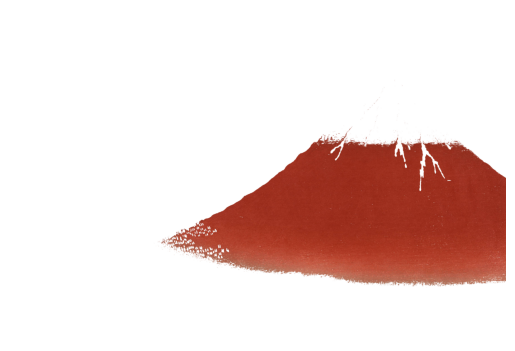

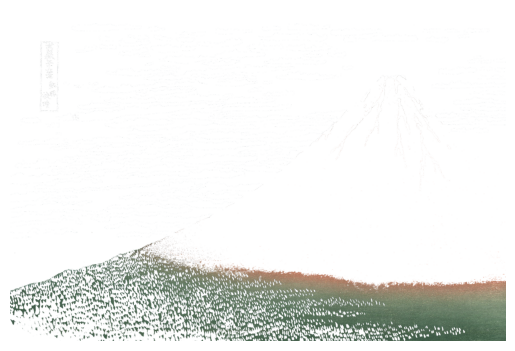

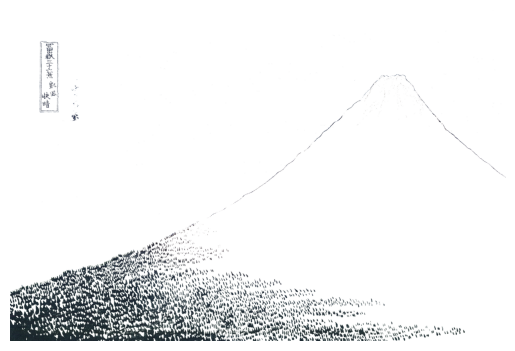

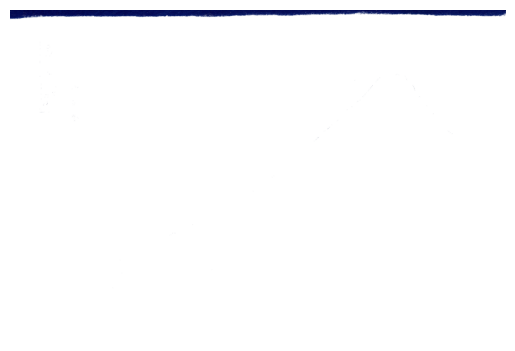

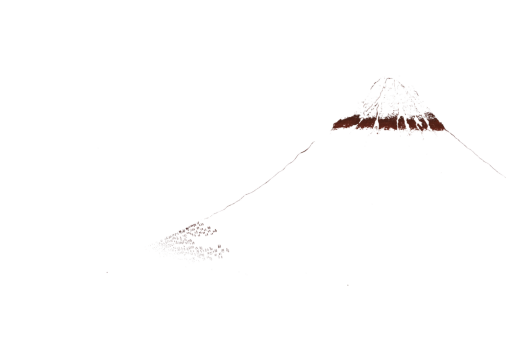

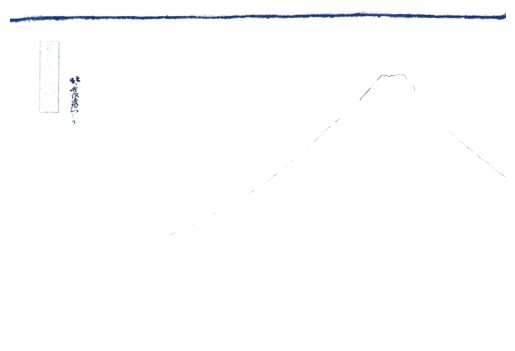

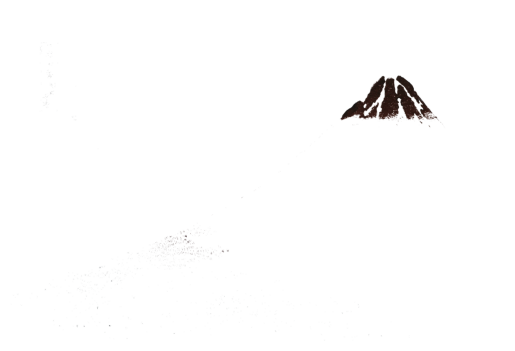

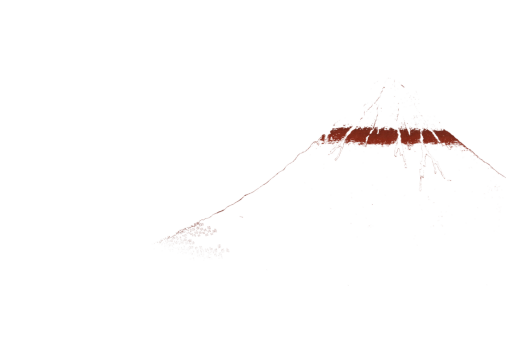

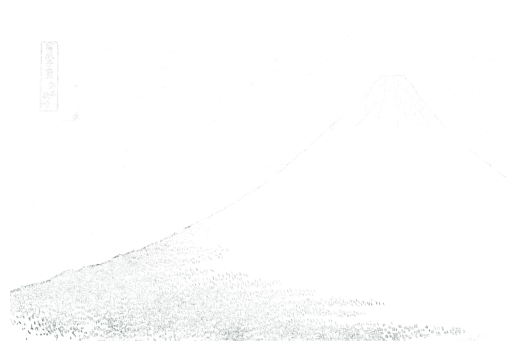

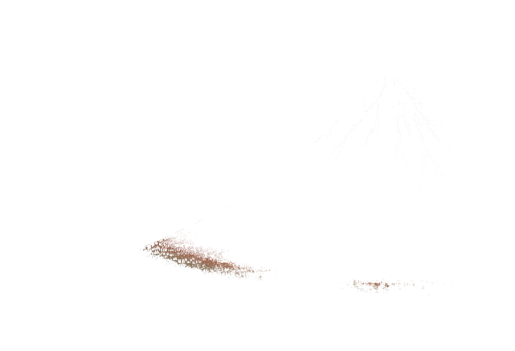

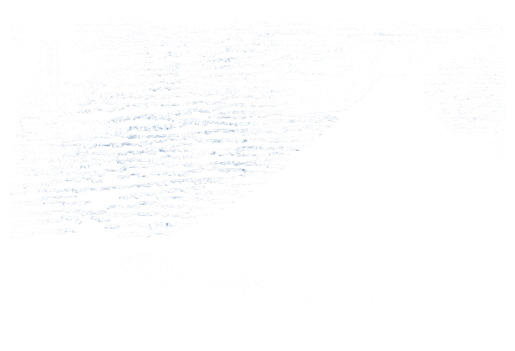

In [287]:
decomposer = WoodblockDecomposer('red_fuji3.jpg')

decomposer.preprocess().compute_gradients().segment_colors()
decomposer.show_layers()

Initial clusters: 30
Final merged clusters: 13
low_energy    :    8 / 76
low_coherence :   73 / 76
weak (AND)    :    8 / 76
Boundaries to merge : 8 / 76


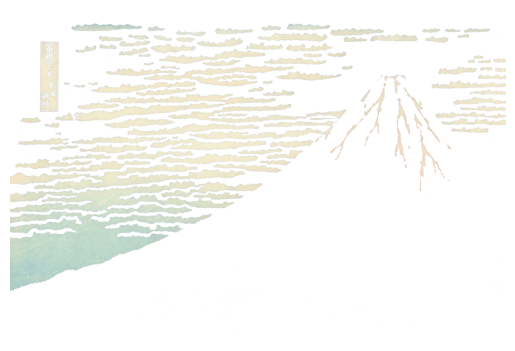

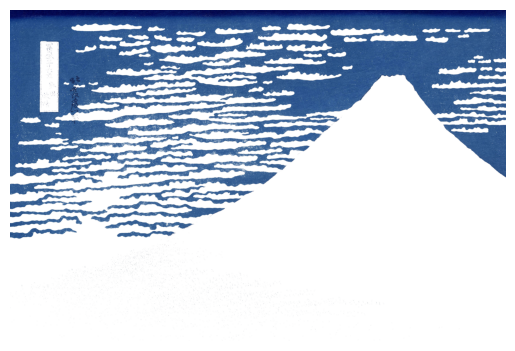

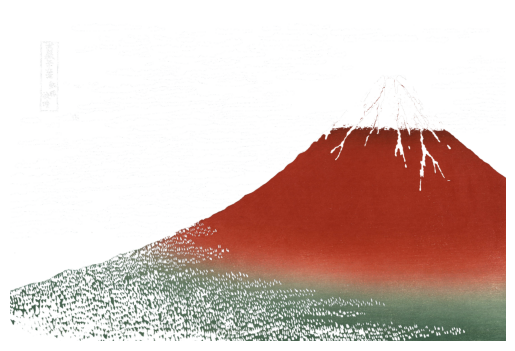

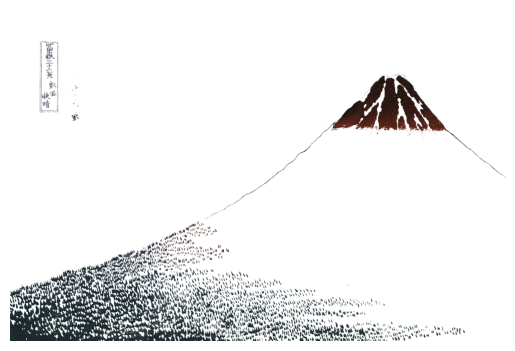

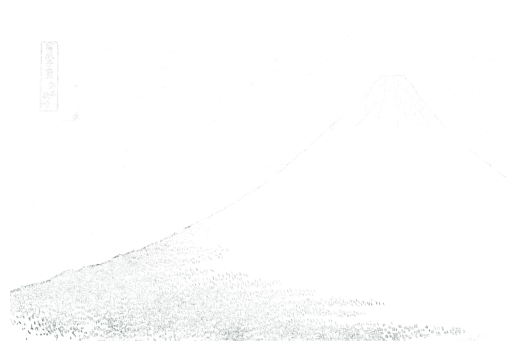

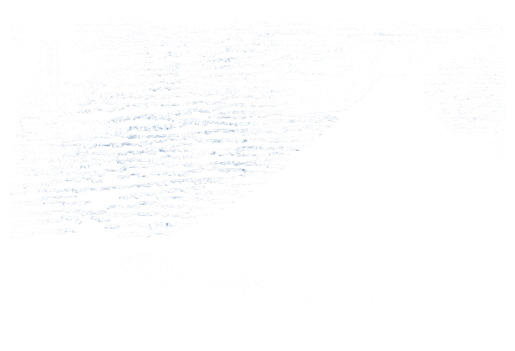

In [295]:
decomposer.preprocess().compute_gradients().segment_colors().merge_boundaries(
    merge_threshold= 0.08, #0.066,     # normalised energy  (tune: 0.10 – 0.25)
    coherence_threshold= 0.93, #0.96,  # structure coherence (tune: 0.4 – 0.75)
    integration_sigma= 1.0     # gradient smoothing scale (tune: 1.0 – 3.0)
)
decomposer.show_layers()
